Diana Itzel Soto Castañeda

Ciencia de Datos para Sensores Inteligentes

# Procesamiento de imagenes

En este notebook se exploran las librerías **Pillow (PIL)**, **OpcenCV**, **Scikit-Image** y **SciPy** para el procesamiento de una imagen con python.

In [3]:
# Imports
import matplotlib.pyplot as plt
import numpy as np
import cv2

## Carga de Imagen con **Pillow**

(np.float64(-0.5), np.float64(3023.5), np.float64(4031.5), np.float64(-0.5))

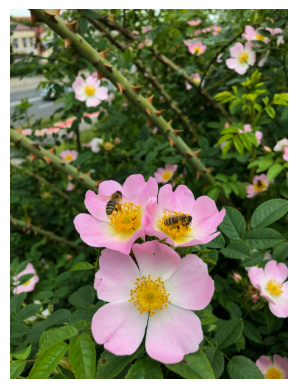

In [4]:
from PIL import Image

# Cargar imagen
img = Image.open("data/Bee_on_flower.jpg")

# Mostrarla
plt.imshow(img)
plt.axis("off")


Para poder hacer operaciones matemáticas sobre la imagen se convierte a un arreglo NumPy

In [5]:
img_np = np.array(img)

print(img_np.shape)
print(img_np.dtype)

(4032, 3024, 3)
uint8


## Pasar la imagén a escala de grises

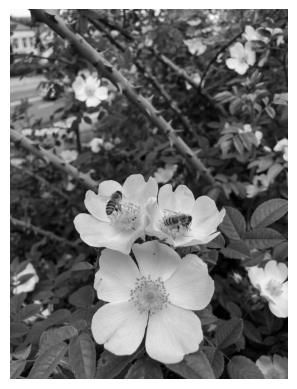

In [6]:
img_gray = img.convert("L")

plt.imshow(img_gray, cmap="gray")
plt.axis("off")
img_np_gray = np.array(img_gray)

Se hace una normalización de la imagen:

In [7]:
img_norm = img_np / 255.0

print(img_norm.min(), img_norm.max(), img_norm.dtype)

0.0 1.0 float64


## Separación de los canales RGB

A cotinuación se separan los canales *Red*, *Green*, y *Blue* y se muestra la contribución de cada canal a la imagen.

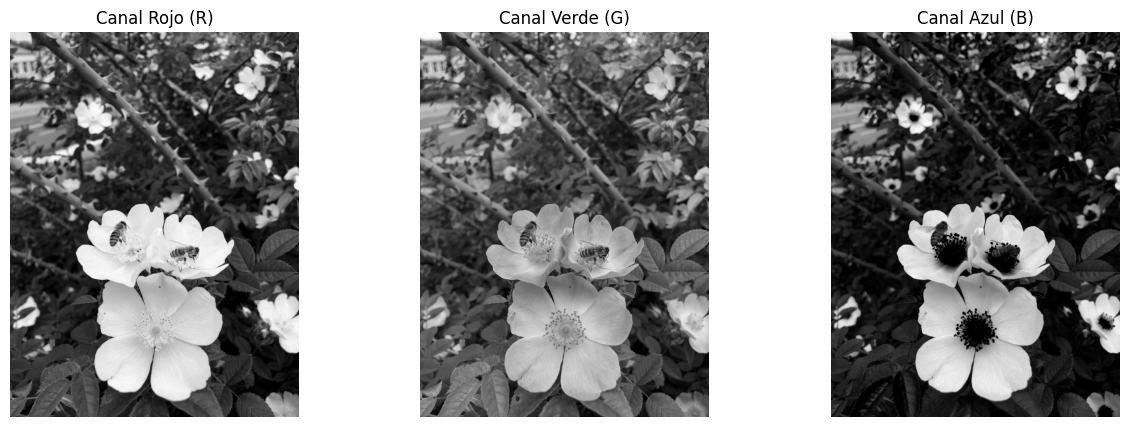

In [8]:
R = img_norm[:, :, 0]
G = img_norm[:, :, 1]
B = img_norm[:, :, 2]
fig, axes = plt.subplots(1, 3, figsize=(15, 5))

axes[0].imshow(R, cmap="gray")
axes[0].set_title("Canal Rojo (R)")
axes[0].axis("off")

axes[1].imshow(G, cmap="gray")
axes[1].set_title("Canal Verde (G)")
axes[1].axis("off")

axes[2].imshow(B, cmap="gray")
axes[2].set_title("Canal Azul (B)")
axes[2].axis("off")

plt.show()


## Detección de bordes con **OpenCV**

A continuación se emplea la librería **OpenCV** para detectar los bordes de la imagen, para ello se hace una comparación de la imagen en escala de grises contra la detección de bordes. Para la detección de bordes se usa el algoritmo Canny el cual permite extraer la información estructural relevante de la imagen.

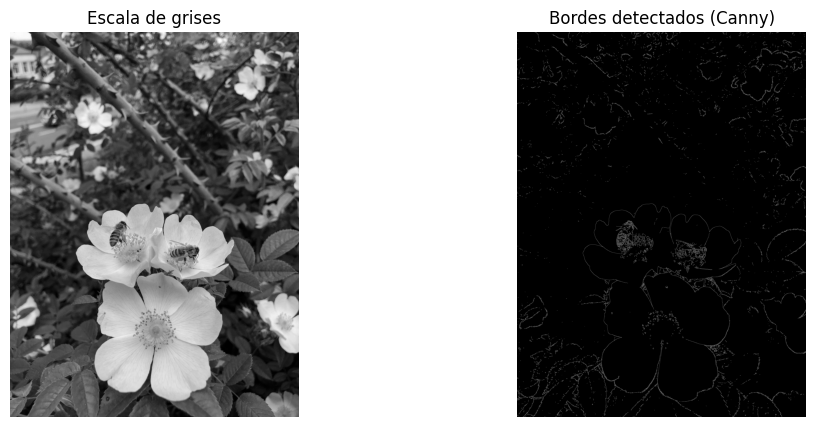

In [9]:
gray_cv = cv2.cvtColor(img_np, cv2.COLOR_RGB2GRAY)
edges = cv2.Canny(gray_cv, threshold1=100, threshold2=200)

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

axes[0].imshow(gray_cv, cmap="gray")
axes[0].set_title("Escala de grises")
axes[0].axis("off")

axes[1].imshow(edges, cmap="gray")
axes[1].set_title("Bordes detectados (Canny)")
axes[1].axis("off")

plt.show()

## Filtros con **OpenCV**

A cotinuación se aplica un suavizado Gaussiano, un Filtro Bilateral, un realce de bordes y un aumento de saturación. Se comparan las salidas de cada procesamiento

In [10]:
blur_gauss = cv2.GaussianBlur(img_np, (15, 15), sigmaX=0)
blur_bilateral = cv2.bilateralFilter(img_np, d=9, sigmaColor=75, sigmaSpace=75)

kernel_sharp = np.array([[0, -1,  0],
                         [-1, 5, -1],
                         [0, -1,  0]])

sharpened = cv2.filter2D(img_np, -1, kernel_sharp)

hsv = cv2.cvtColor(img_np, cv2.COLOR_RGB2HSV)

h, s, v = cv2.split(hsv)
s = cv2.add(s, 50)  # aumenta saturación
s = np.clip(s, 0, 255)
hsv_sat = cv2.merge([h, s, v])
img_sat = cv2.cvtColor(hsv_sat, cv2.COLOR_HSV2RGB)


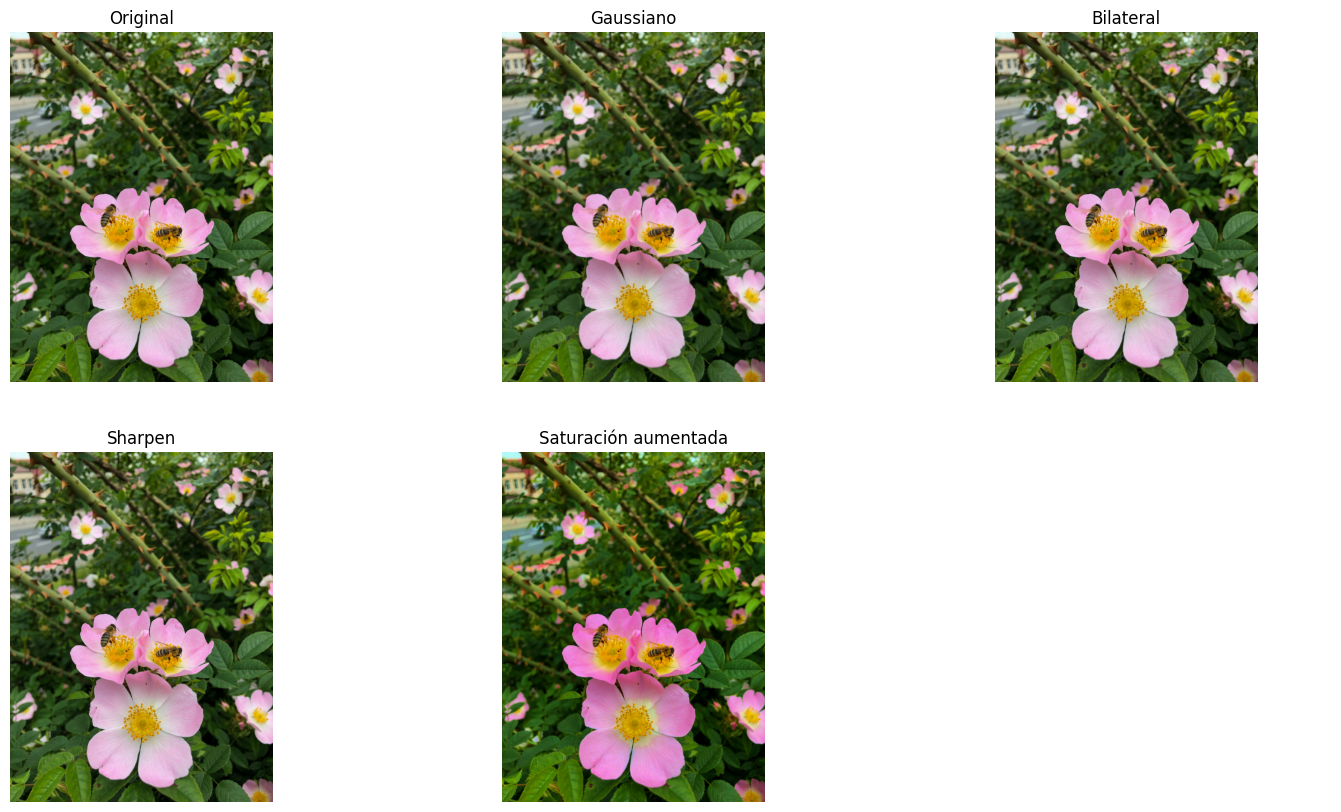

In [11]:
fig, axes = plt.subplots(2, 3, figsize=(18, 10))

axes[0,0].imshow(img_np)
axes[0,0].set_title("Original")
axes[0,0].axis("off")

axes[0,1].imshow(blur_gauss)
axes[0,1].set_title("Gaussiano")
axes[0,1].axis("off")

axes[0,2].imshow(blur_bilateral)
axes[0,2].set_title("Bilateral")
axes[0,2].axis("off")

axes[1,0].imshow(sharpened)
axes[1,0].set_title("Sharpen")
axes[1,0].axis("off")

axes[1,1].imshow(img_sat)
axes[1,1].set_title("Saturación aumentada")
axes[1,1].axis("off")

axes[1,2].axis("off")

plt.show()


## Multiplicación de saturación y valor con **CV**

(np.float64(-0.5), np.float64(3023.5), np.float64(4031.5), np.float64(-0.5))

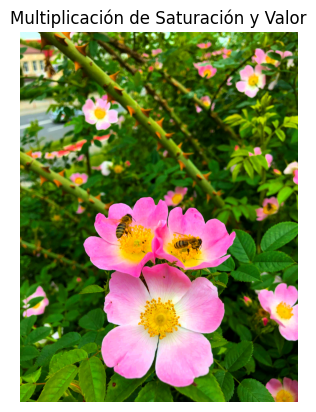

In [20]:
hsv = cv2.cvtColor(img_np, cv2.COLOR_RGB2HSV)

h, s, v = cv2.split(hsv)
s = cv2.multiply(s, 1.8)
v = cv2.multiply(v, 1.2)

s = np.clip(s, 0, 255)
v = np.clip(v, 0, 255)

pop = cv2.merge([h, s.astype(np.uint8), v.astype(np.uint8)])
pop = cv2.cvtColor(pop, cv2.COLOR_HSV2RGB)

plt.imshow(pop)
plt.title("Multiplicación de Saturación y Valor")
plt.axis("off")


## Segmentación por umbral con **Scikit-Image**

In [13]:
from skimage.filters import threshold_otsu

Umbral: 116


(np.float64(-0.5), np.float64(3023.5), np.float64(4031.5), np.float64(-0.5))

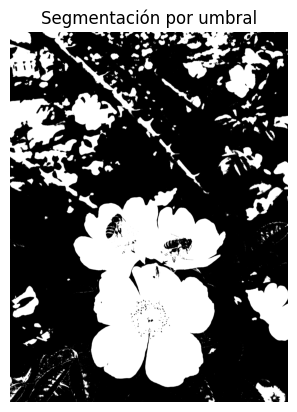

In [14]:
th = threshold_otsu(gray_cv)
print("Umbral:", th)
binary = gray_cv > th

plt.imshow(binary, cmap="gray")
plt.title("Segmentación por umbral")
plt.axis("off")


## Transformada rápida de Fourier (FFT) con **SciPy**

In [15]:
from scipy.fft import fft2, fftshift

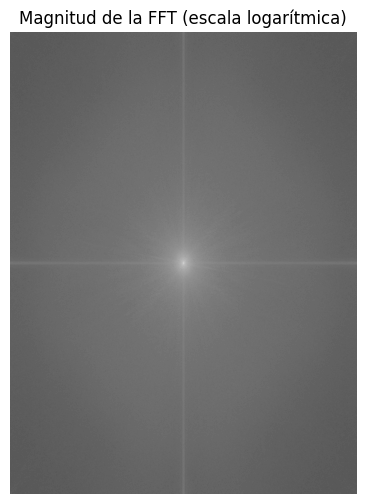

In [16]:
#Transformar la imagen a frecuencias
F = fft2(gray_cv)
F_shift = fftshift(F)
magnitude = np.log(np.abs(F_shift) + 1) # Magnitud en escala logarítmica

# Visualizar
plt.figure(figsize=(6, 6))
plt.imshow(magnitude, cmap="gray")
plt.title("Magnitud de la FFT (escala logarítmica)")
plt.axis("off")
plt.show()


## Conclusion

En esta práctica se aplicaron distintas técnicas de procesamiento de imágenes utilizando librerías de Python como NumPy, OpenCV, Scikit-Image y SciPy. La imagen fue tratada como un arreglo numérico, permitiendo realizar operaciones de normalización, filtrado, segmentación y análisis en el dominio de la frecuencia. Los resultados muestran cómo una imagen digital puede analizarse y transformarse mediante herramientas computacionales.